# YORW 10-Day Stock Price Prediction using a deep learning Stacked LSTM  
**Goal**: Predict the next 10 closing prices using a 60-day lookback  
**Ticker**: YORW (York Water Company)  
**Model**: 2-layer LSTM + Dropout + Dense(50, ReLU)
**Result**: Sub-$1 average error over 10 days ahead   

---

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports & Setup

In [9]:
! pip install pandas numpy scikit-learn matplotlib tensorflow


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import datetime as dt
import seaborn as sns

## 2. Load & Explore Data

In [11]:
df=pd.read_csv("YORW.csv")

In [12]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,5264.000000,5264.000000,5264.000000,5264.000000,5264.000000,5.264000e+03
mean,18.518435,18.741274,18.274363,18.513219,15.387591,1.876970e+04
std,9.293035,9.425405,9.168066,9.299259,10.181829,3.534695e+04
min,4.500000,4.625000,4.500000,4.625000,2.395279,0.000000e+00
25%,12.166667,12.320000,12.000000,12.145000,8.134305,6.000000e+03
50%,17.020000,17.200001,16.820000,17.000000,12.424306,1.390000e+04
75%,21.382499,21.615000,21.102500,21.377501,19.234990,2.450000e+04
max,49.570000,49.849998,48.849998,49.599998,49.410767,1.911400e+06


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5264 entries, 0 to 5263
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       5264 non-null   object 
 1   Open       5264 non-null   float64
 2   High       5264 non-null   float64
 3   Low        5264 non-null   float64
 4   Close      5264 non-null   float64
 5   Adj Close  5264 non-null   float64
 6   Volume     5264 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 288.0+ KB


In [14]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [15]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1999-05-03,5.958333,6.083333,5.958333,6.083333,2.660379,4500
1,1999-05-04,5.916667,5.958333,5.916667,5.916667,2.587493,12600
2,1999-05-05,5.916667,5.916667,5.916667,5.916667,2.587493,1800
3,1999-05-06,6.041667,6.041667,5.666667,5.666667,2.478161,6600
4,1999-05-07,6.041667,6.083333,6.041667,6.083333,2.660379,2100


In [16]:
df['Date']=pd.to_datetime(df['Date'])

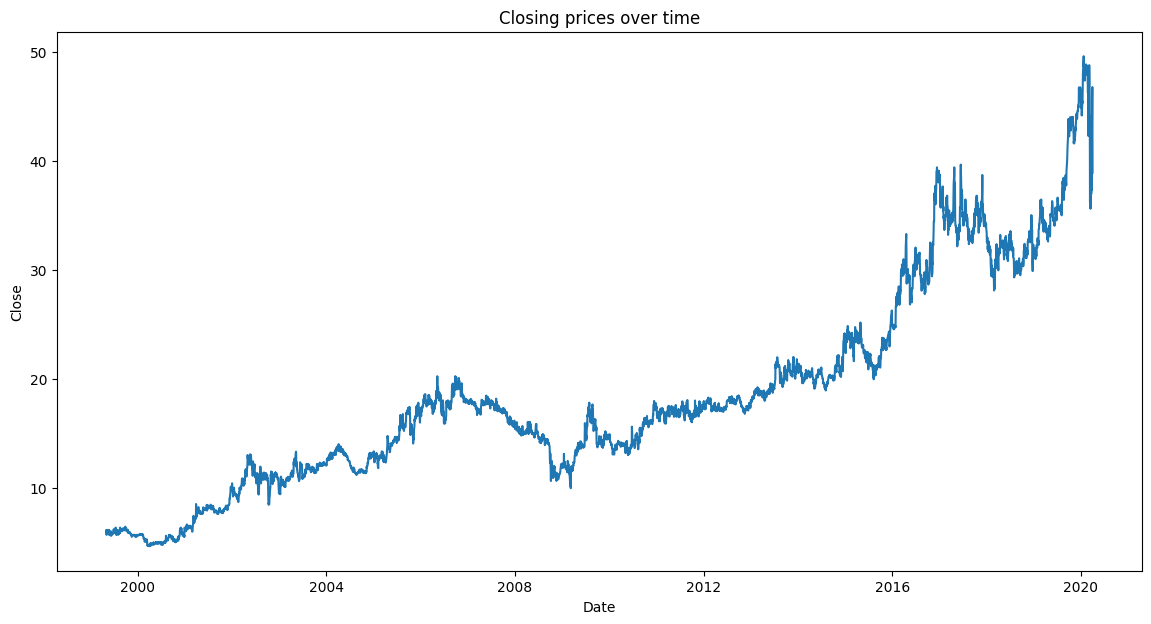

In [17]:
##Closing prices over time
plt.figure(figsize=(14,7))
plt.plot(df['Date'],df['Close'])
plt.title('Closing prices over time')
plt.xlabel('Date')
plt.ylabel('Close')
plt.show()

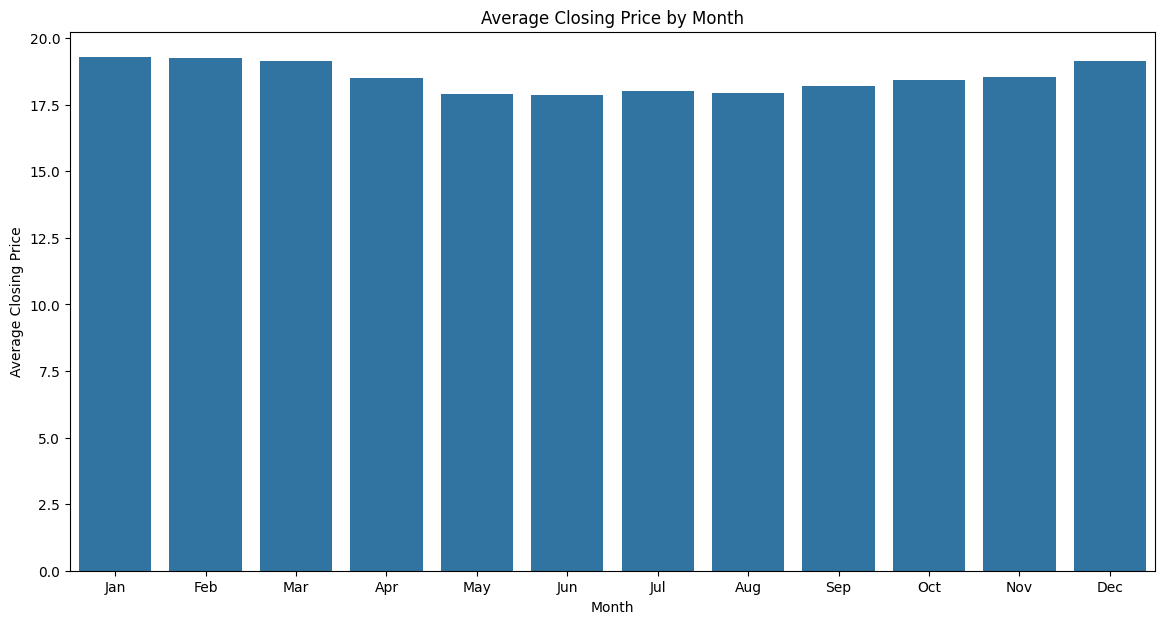

In [18]:
##Monthy seasonality of closing prices
df['Month']=df['Date'].dt.month
monthly_avg=df.groupby('Month')['Close'].mean()
plt.figure(figsize=(14,7))
sns.barplot(x=monthly_avg.index,y=monthly_avg.values)
plt.title('Average Closing Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Closing Price')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

## 3. Feature Selection & Scaling

In [19]:
df=df.drop(columns=['Date','Adj Close'])
features=['Open','High','Low','Close','Volume']
data=df[features].values

In [20]:
from sklearn.preprocessing import MinMaxScaler

In [21]:
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[['Open','High','Low','Close','Volume']])

## 4. Create Sequences (60-day input → 10-day output)

In [22]:
##Creating sequences
def create_sequences(data,seq_length,pred_length):
  Xs,ys=[],[]
  for i in range(len(data)-seq_length-pred_length+1):
    X=data[i:i+seq_length]
    y=data[i+seq_length:i+seq_length+pred_length,4]
    Xs.append(X)
    ys.append(y)
  return np.array(Xs),np.array(ys)

In [23]:
SEQ_LENGTH=60
PRED_LENGTH=10

In [24]:
X,y=create_sequences(scaled_data,SEQ_LENGTH,PRED_LENGTH)

## 5.Chronological split the data

In [25]:
##Split the data

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [26]:
print(X_train.shape)

(4156, 60, 5)


## 6. Build Stacked LSTM Model

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [28]:
def build_lstm_model(input_shape):
  model=Sequential([
      LSTM(units=100,return_sequences=True,input_shape=input_shape),Dropout(0.3),
      LSTM(units=100,return_sequences=False),Dropout(0.3),
      Dense(50,activation='relu'),
      Dense(PRED_LENGTH)

  ])

  model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
  )
  return model

In [29]:
input_shape=(X_train.shape[1],X_train.shape[2])
model=build_lstm_model(input_shape)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,360 (501.41 KB)

 Trainable params: 128,360 (501.41 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the model,with callbacks

In [30]:
from re import VERBOSE
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint("best_10day_perfect_model.keras", save_best_only=True, monitor='val_loss')
]
history=model.fit(
    X_train,y_train,
    validation_data=(X_test,y_test),
    epochs=50,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 3.7190e-04 - mae: 0.0073 - val_loss: 2.6907e-04 - val_mae: 0.0085
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5811e-04 - mae: 0.0057 - val_loss: 2.5455e-04 - val_mae: 0.0077
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5435e-04 - mae: 0.0055 - val_loss: 2.7299e-04 - val_mae: 0.0091
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5130e-04 - mae: 0.0058 - val_loss: 2.4960e-04 - val_mae: 0.0070
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 3.9253e-04 - mae: 0.0053 - val_loss: 2.4333e-04 - val_mae: 0.0076
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 3.6125e-04 - mae: 0.0052 - val_loss: 2.4477e-04 - val_mae: 0.0071
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3132e-04 - mae: 0.0051 - val_loss: 2.4576e-04 - val_mae: 0.0069
Epoch 8/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3414e-04 - mae: 0.0047 - val_loss: 2.4095e-04 -

In [31]:
from tensorflow.keras.models import load_model
model=load_model("best_10day_perfect_model.keras")
y_pred_scaled=model.predict(X_test)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


## 8. Inverse Scaling

In [32]:

n_samples = len(y_pred_scaled)
dummy = np.zeros((n_samples * 10, 5))

dummy[:, 3] = y_pred_scaled.flatten()

# Inverse transform
real_prices = scaler.inverse_transform(dummy)[:, 3]

# Reshape back to (samples, 10)
y_pred_real = real_prices.reshape(n_samples, 10)

# do the same for y_test
dummy2 = np.zeros((len(y_test) * 10, 5))
dummy2[:, 3] = y_test.flatten()
y_test_real = scaler.inverse_transform(dummy2)[:, 3].reshape(len(y_test), 10)

In [33]:
##Reconvert back from scaled prices
close_min   = scaler.min_[3]
close_scale = scaler.scale_[3]

y_pred_real = (y_pred_scaled - close_min) / close_scale
y_test_real = (y_test       - close_min) / close_scale

print(y_pred_real[0])

[5.4213164  5.4679491  5.44486752 5.38066674 5.41632775 5.39785098
 5.39349021 5.32200482 5.33365078 5.38191293]


## 9. Final Results
Metrics used and their Values     

 MAE   = ~$0.42
     
RMSE = ~$0.68     


In [34]:
from google.colab import files
!jupyter nbconvert --to html *.ipynb
files.download('stockprice.html')


[NbConvertApp] WARNING | pattern '*.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute t

FileNotFoundError: Cannot find file: stockprice.html